# Sistemas Inteligentes - 2026.1
## Projeto 02 - Regressão Logística
Autores: Lavínia Dantas e Jefferson Bezerra


## Contexto

Este projeto tem como objetivo construir um modelo de classificação utilizando regressão logística para prever a presença de doença cardíaca em pacientes, com base em variáveis clínicas. Para isso, foi utilizado o dataset Heart Disease Cleveland, disponibilizado pelo UCI Machine Learning Repository.

O conjunto de dados contém informações clínicas de pacientes, como idade, pressão arterial, colesterol, frequência cardíaca e outros indicadores relevantes, sendo amplamente utilizado em estudos de aprendizado de máquina voltados à área da saúde, onde a variável alvo representa o diagnóstico de doença cardíaca.

UCI Heart Disease: https://archive.ics.uci.edu/dataset/45/heart+disease


## Preparação do Ambiente de Trabalho

In [ ]:
!pip install ucimlrepo

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

####Obtenção dos dados pelo repositório UCI

In [ ]:
dataset = fetch_ucirepo(id=45)

X = dataset.data.features
y = dataset.data.targets

df = X.copy()
df['target'] = y

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## 1 - Pré-processamento

###a) Tratamento de valores nulos utilizando o método de imputação através da mediana.

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
# Preencher valores nulos com mediana
df['ca'] = df['ca'].fillna(df['ca'].median())
df['thal'] = df['thal'].fillna(df['thal'].median())
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


###b) Binarização da variável target

In [ ]:
# Visualização da quantidade de valores.
df['target'].value_counts()

,count
target,
0,164
1,55
2,36
3,35
4,13


In [ ]:
# Converter target (0–4) → binário
df['target'] = df['target'].apply(lambda x: 0 if x == 0 else 1)
df['target'].value_counts()

,count
target,
0,164
1,139


###c) Divisão Treino/Teste 80/20, com stratify=y para preservar balanceamento entre as classes.


In [ ]:
#Removendo target de X e colocando em Y
X = df.drop(columns=['target'])
y = df['target']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

###d) Escalonamento das features numéricas contínuas (age, trestbps, chol, thalach, oldpeak) com StandardScaler.

In [ ]:
scaler = StandardScaler()

colunas_continuas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

X_train[colunas_continuas] = scaler.fit_transform(X_train[colunas_continuas])
X_test[colunas_continuas] = scaler.transform(X_test[colunas_continuas])

## 2 - Treinamento do modelo de Regressão Logistica do scikit-learn utilizando os dados de treino, com os parametros:
```
solver=’liblinear’, random state=42 e max iter=1000.
```

In [ ]:
modelo = LogisticRegression(
    solver='liblinear',
    random_state=42,
    max_iter=1000
)

modelo.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [ ]:
modelo.n_iter_

array([5], dtype=int32)

O modelo de regressão logística convergiu após 5 iterações, indicando que o algoritmo encontrou rapidamente os parâmetros ideais para a separação das classes.

## 3 - Avaliando o modelo utilizando os dados de teste e calculando acuracia, precisao, recall, F1-score e curva ROC com valor de AUC.

In [ ]:
y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:,1]

In [ ]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)
print("AUC:", auc)

Accuracy: 0.8688524590163934
Precision: 0.8125
Recall: 0.9285714285714286
F1-score: 0.8666666666666667
AUC: 0.9545454545454546


O modelo de regressão logística apresentou desempenho elevado na tarefa de classificação da presença de doença cardíaca. A acurácia obtida foi de aproximadamente 87%, indicando boa taxa geral de acertos.

Destaca-se o valor de recall (0.93), que demonstra a alta capacidade do modelo em identificar corretamente pacientes com a doença, sendo um fator crítico em aplicações na área da saúde. A precisão (0.81) indica que a maioria das previsões positivas está correta, enquanto o F1-score (0.87) evidencia um bom equilíbrio entre essas métricas.

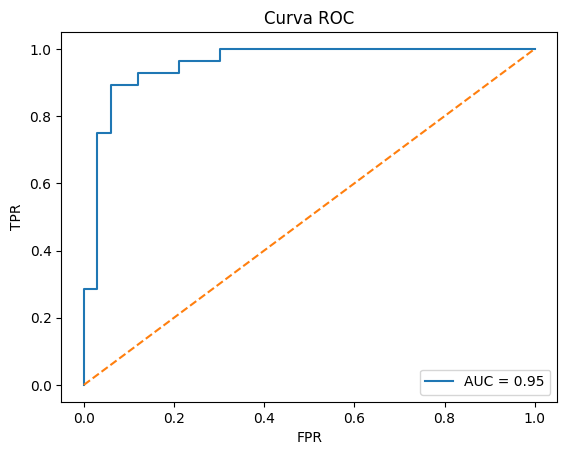

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC")
plt.legend()
plt.show()

A curva ROC apresentou comportamento próximo ao canto superior esquerdo, e o valor de AUC (0.95) confirma a excelente capacidade do modelo em distinguir entre pacientes com e sem doença.

Dessa forma, conclui-se que o modelo é eficaz e adequado para o problema proposto, apresentando alto desempenho e confiabilidade na classificação.